<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/descomposicion_canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición Canónica de una Cadena de Markov


En esta notebook se analiza la matriz de transición P del problema. Primero se escribe la matriz y se dibuja su diagrama de transiciones, luego se determina si tiene distribución límite, después se obtiene la descomposición canónica junto con el límite de $P^n$, y al final se programa una función general que hace todo esto para cualquier matriz.


In [ ]:
# Cargamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from fractions import Fraction

print('Librerías cargadas correctamente')


Librerías cargadas correctamente


---
## Matriz de transición P y diagrama


In [15]:
# Se escribe la matriz P tal como viene en el problema
# Los estados a, b, c, d, e, f, g corresponden a los índices 0 al 6

estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
n = len(estados)

P = np.array([
    [1/4,   0,    0,    0,    0,    0,   3/4],   # a
    [1/8,  1/8,  1/4,   0,   1/4,  1/8, 1/8],   # b
    [ 0,    0,   2/5,  1/5,  2/5,   0,   0 ],   # c
    [ 0,    0,   1/2,  1/2,   0,    0,   0 ],   # d
    [ 0,    0,    0,   1/2,  1/2,   0,   0 ],   # e
    [ 0,   1/5,   0,   1/5,  1/5,  1/5, 1/5],   # f
    [4/5,   0,    0,    0,    0,    0,  1/5]    # g
])

# Se verifica que cada renglón sume 1 (condición de matriz estocástica)
print('Verificación de sumas por renglón:')
for i, s in enumerate(estados):
    print(f'  Estado {s}: suma = {P[i].sum()}')

# Se imprime la matriz de forma legible con fracciones
print()
print('Matriz P:')
print('        ' + ''.join(f'{s:^8}' for s in estados))
for i, s in enumerate(estados):
    fila = ''.join(f'{str(Fraction(P[i,j]).limit_denominator(100)):^8}' for j in range(n))
    print(f'  {s}   [ {fila}]')

Verificación de sumas por renglón:
  Estado a: suma = 1.0
  Estado b: suma = 1.0
  Estado c: suma = 1.0
  Estado d: suma = 1.0
  Estado e: suma = 1.0
  Estado f: suma = 1.0
  Estado g: suma = 1.0

Matriz P:
           a       b       c       d       e       f       g    
  a   [   1/4      0       0       0       0       0      3/4   ]
  b   [   1/8     1/8     1/4      0      1/4     1/8     1/8   ]
  c   [    0       0      2/5     1/5     2/5      0       0    ]
  d   [    0       0      1/2     1/2      0       0       0    ]
  e   [    0       0       0      1/2     1/2      0       0    ]
  f   [    0      1/5      0      1/5     1/5     1/5     1/5   ]
  g   [   4/5      0       0       0       0       0      1/5   ]


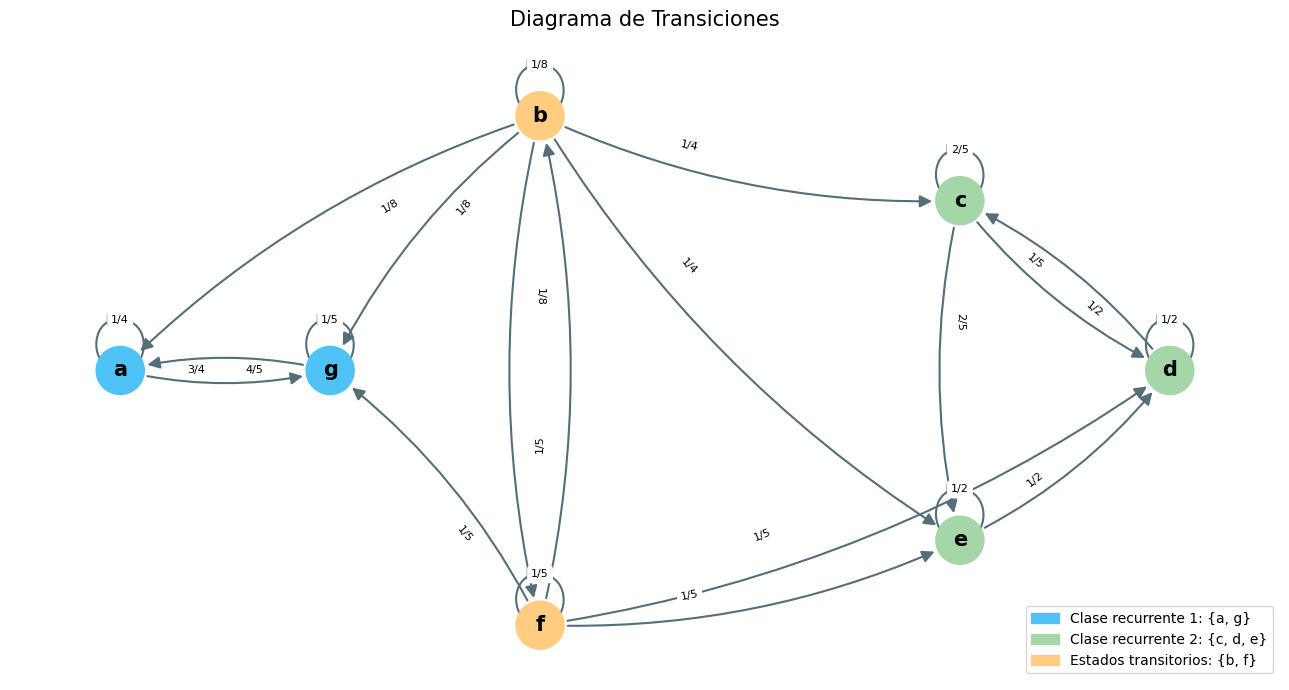

In [16]:
# Se construye el grafo dirigido para el diagrama de transiciones
G = nx.DiGraph()
G.add_nodes_from(estados)

for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G.add_edge(estados[i], estados[j], prob=P[i, j])

# Los nodos se acomodan a mano para que se distingan las clases visualmente
pos = {
    'a': (-2,  0),
    'g': (-1,  0),
    'b': ( 0,  1.5),
    'f': ( 0, -1.5),
    'c': ( 2,  1),
    'd': ( 3,  0),
    'e': ( 2, -1),
}

# Colores según el tipo de estado (se asignan después del análisis de clases)
colores = {'a': '#4fc3f7', 'g': '#4fc3f7',
           'c': '#a5d6a7', 'd': '#a5d6a7', 'e': '#a5d6a7',
           'b': '#ffcc80', 'f': '#ffcc80'}
color_lista = [colores[s] for s in estados]

fig, ax = plt.subplots(figsize=(13, 7))

nx.draw_networkx_nodes(G, pos, node_color=color_lista, node_size=1200, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=15, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=18,
                       connectionstyle='arc3,rad=0.12',
                       edge_color='#546e7a', width=1.5, ax=ax,
                       min_source_margin=20, min_target_margin=20)

# Las etiquetas se convierten a fracción para que se vean más limpias
edge_labels = {}
for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            frac = Fraction(P[i, j]).limit_denominator(100)
            edge_labels[(estados[i], estados[j])] = str(frac)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=8, label_pos=0.35, ax=ax)

p1 = mpatches.Patch(color='#4fc3f7', label='Clase recurrente 1: {a, g}')
p2 = mpatches.Patch(color='#a5d6a7', label='Clase recurrente 2: {c, d, e}')
p3 = mpatches.Patch(color='#ffcc80', label='Estados transitorios: {b, f}')
ax.legend(handles=[p1, p2, p3], loc='lower right', fontsize=10)

ax.set_title('Diagrama de Transiciones', fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('diagrama_transiciones.png', dpi=120, bbox_inches='tight')
plt.show()


---
## ¿Tiene distribución límite?

Para que una cadena de Markov tenga **distribución límite única**, se necesita que sea irreducible (todos los estados se comunican entre sí) y aperiódica. Para verificarlo, se identifican las clases comunicantes y se determina si la cadena es irreducible.


In [17]:
# Se construye el grafo con índices enteros para aprovechar los algoritmos de networkx
G_idx = nx.DiGraph()
for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G_idx.add_edge(i, j)

# Las componentes fuertemente conexas corresponden a las clases comunicantes
sccs = list(nx.strongly_connected_components(G_idx))

print('=== Clases comunicantes ===')
for k, scc in enumerate(sorted(sccs, key=lambda s: min(s))):
    nombres = [estados[i] for i in sorted(scc)]
    print(f'  Clase {k+1}: {nombres}')

print()

# Se clasifica cada clase como recurrente (cerrada) o transitoria.
# Una clase es cerrada si desde ninguno de sus estados se puede salir hacia afuera.
clases_recurrentes = []
estados_transitorios = []

for scc in sccs:
    puede_salir = False
    for i in scc:
        for j in range(n):
            if P[i, j] > 1e-12 and j not in scc:
                puede_salir = True
                break
        if puede_salir:
            break

    nombres = [estados[i] for i in sorted(scc)]
    if not puede_salir:
        clases_recurrentes.append(sorted(list(scc)))
        print(f'  RECURRENTE (cerrada): {nombres}')
    else:
        estados_transitorios.extend(sorted(list(scc)))
        print(f'  TRANSITORIA:          {nombres}')

print()
print('Resumen:')
print(f'  Clases recurrentes  : {[[estados[i] for i in c] for c in clases_recurrentes]}')
print(f'  Estados transitorios: {[estados[i] for i in sorted(estados_transitorios)]}')


=== Clases comunicantes ===
  Clase 1: ['a', 'g']
  Clase 2: ['b', 'f']
  Clase 3: ['c', 'd', 'e']

  RECURRENTE (cerrada): ['a', 'g']
  RECURRENTE (cerrada): ['c', 'd', 'e']
  TRANSITORIA:          ['b', 'f']

Resumen:
  Clases recurrentes  : [['a', 'g'], ['c', 'd', 'e']]
  Estados transitorios: ['b', 'f']




La cadena **no tiene distribución límite única** porque no es irreducible: existen dos clases recurrentes, $\{a, g\}$ y $\{c, d, e\}$, y los estados $b$ y $f$ son transitorios (desde ellos se puede llegar a cualquiera de las dos clases). El comportamiento a largo plazo depende entonces del estado inicial.

Dicho esto, el límite de $P^n$ **sí existe** porque todas las clases recurrentes son aperiódicas — todas tienen lazos, es decir, probabilidad positiva de quedarse en el mismo estado.


---
## Descomposición canónica y límite de $P^n$

La **forma canónica** reordena los estados poniendo primero las clases recurrentes y después los estados transitorios, de modo que la matriz queda en bloques:

$$P_{\text{canon}} = \begin{pmatrix} B_1 & 0 & 0 \\ 0 & B_2 & 0 \\ R_1 & R_2 & Q \end{pmatrix}$$

donde $B_1$ y $B_2$ son las submatrices de las clases recurrentes, $Q$ es la submatriz entre los transitorios, y $R_1$, $R_2$ describen cómo los transitorios transitan hacia cada clase.


In [20]:
# Se reordenan los estados: primero las clases recurrentes, luego los transitorios
nuevo_orden = []
for clase in clases_recurrentes:
    nuevo_orden.extend(clase)
nuevo_orden.extend(sorted(estados_transitorios))

estados_canon = [estados[i] for i in nuevo_orden]
print('Nuevo orden de estados:', estados_canon)

P_canon = P[np.ix_(nuevo_orden, nuevo_orden)]

print()
print('Matriz en forma canónica:')
print('        ' + ''.join(f'{s:^8}' for s in estados_canon))
for i, s in enumerate(estados_canon):
    fila = ''.join(f'{str(Fraction(P_canon[i,j]).limit_denominator(100)):^8}' for j in range(n))
    print(f'  {s}   [ {fila}]')

# Se extraen los bloques de la forma canónica
n1 = len(clases_recurrentes[0])   # tamaño de {a, g}
n2 = len(clases_recurrentes[1])   # tamaño de {c, d, e}

B1 = P_canon[:n1, :n1]
B2 = P_canon[n1:n1+n2, n1:n1+n2]
Q  = P_canon[n1+n2:, n1+n2:]
R1 = P_canon[n1+n2:, :n1]
R2 = P_canon[n1+n2:, n1:n1+n2]

print('\nBloque B1 (clase {a, g}):')
print(B1)
print('Bloque B2 (clase {c, d, e}):')
print(B2)
print('Bloque Q (transitorios {b, f}):')
print(Q)
print('Bloque R1 (transitorios -> {a, g}):')
print(R1)
print('Bloque R2 (transitorios -> {c, d, e}):')
print(R2)


Nuevo orden de estados: ['a', 'g', 'c', 'd', 'e', 'b', 'f']

Matriz en forma canónica:
           a       g       c       d       e       b       f    
  a   [   1/4     3/4      0       0       0       0       0    ]
  g   [   4/5     1/5      0       0       0       0       0    ]
  c   [    0       0      2/5     1/5     2/5      0       0    ]
  d   [    0       0      1/2     1/2      0       0       0    ]
  e   [    0       0       0      1/2     1/2      0       0    ]
  b   [   1/8     1/8     1/4      0      1/4     1/8     1/8   ]
  f   [    0      1/5      0      1/5     1/5     1/5     1/5   ]

Bloque B1 (clase {a, g}):
[[0.25 0.75]
 [0.8  0.2 ]]
Bloque B2 (clase {c, d, e}):
[[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]
Bloque Q (transitorios {b, f}):
[[0.125 0.125]
 [0.2   0.2  ]]
Bloque R1 (transitorios -> {a, g}):
[[0.125 0.125]
 [0.    0.2  ]]
Bloque R2 (transitorios -> {c, d, e}):
[[0.25 0.   0.25]
 [0.   0.2  0.2 ]]


In [21]:
# Se calcula la distribución estacionaria de cada submatriz recurrente.
# Se resuelve el sistema  pi @ B = pi  con  sum(pi) = 1,
# lo cual equivale a  pi @ (B - I) = 0  más la condición de normalización.

def dist_estacionaria(B):
    m = len(B)
    A = np.zeros((m, m))
    A[:-1] = (B.T - np.eye(m))[:-1]  # ecuaciones de balance
    A[-1]  = np.ones(m)               # condición sum = 1
    b = np.zeros(m)
    b[-1] = 1
    return np.linalg.solve(A, b)

print('=== Distribuciones estacionarias de las clases recurrentes ===')
print()

nombres_B1 = [estados[i] for i in clases_recurrentes[0]]
pi_B1 = dist_estacionaria(B1)
print(f'Clase 1: {nombres_B1}')
for s, p in zip(nombres_B1, pi_B1):
    frac = Fraction(p).limit_denominator(200)
    print(f'  pi({s}) = {p:.8f}  ≈  {frac}')
print(f'  Suma = {pi_B1.sum():.6f}')
print()

nombres_B2 = [estados[i] for i in clases_recurrentes[1]]
pi_B2 = dist_estacionaria(B2)
print(f'Clase 2: {nombres_B2}')
for s, p in zip(nombres_B2, pi_B2):
    frac = Fraction(p).limit_denominator(200)
    print(f'  pi({s}) = {p:.8f}  ≈  {frac}')
print(f'  Suma = {pi_B2.sum():.6f}')


=== Distribuciones estacionarias de las clases recurrentes ===

Clase 1: ['a', 'g']
  pi(a) = 0.51612903  ≈  16/31
  pi(g) = 0.48387097  ≈  15/31
  Suma = 1.000000

Clase 2: ['c', 'd', 'e']
  pi(c) = 0.33333333  ≈  1/3
  pi(d) = 0.40000000  ≈  2/5
  pi(e) = 0.26666667  ≈  4/15
  Suma = 1.000000


In [22]:
# Se calcula el límite de P^n cuadrando la matriz repetidamente.
# Después de 30 cuadrados se tienen 2^30 pasos, más que suficiente para converger.

P_lim = P.copy()
for _ in range(30):
    P_lim = P_lim @ P_lim

print('Límite de P^n:')
print('        ' + ''.join(f'{s:^8}' for s in estados))
for i, s in enumerate(estados):
    fila = ''.join(f'{P_lim[i,j]:^8.4f}' for j in range(n))
    print(f'  {s}   [ {fila}]')


Límite de P^n:
           a       b       c       d       e       f       g    
  a   [  0.5161  0.0000  0.0000  0.0000  0.0000  0.0000  0.4839 ]
  b   [  0.1720  0.0000  0.2222  0.2667  0.1778  0.0000  0.1613 ]
  c   [  0.0000  0.0000  0.3333  0.4000  0.2667  0.0000  0.0000 ]
  d   [  0.0000  0.0000  0.3333  0.4000  0.2667  0.0000  0.0000 ]
  e   [  0.0000  0.0000  0.3333  0.4000  0.2667  0.0000  0.0000 ]
  f   [  0.1720  0.0000  0.2222  0.2667  0.1778  0.0000  0.1613 ]
  g   [  0.5161  0.0000  0.0000  0.0000  0.0000  0.0000  0.4839 ]


In [23]:
# Se comparan los renglones límite con las distribuciones estacionarias

print('=== Comparación con las distribuciones estacionarias ===')
print()
print('Para los estados de la clase {a, g}, el renglón límite debe coincidir con pi_B1:')
for s in nombres_B1:
    i = estados.index(s)
    renglon = P_lim[i, [estados.index(x) for x in nombres_B1]]
    print(f'  Renglón {s} en P^inf : {renglon}')
print(f'  pi_B1               : {pi_B1}')

print()
print('Para los estados de la clase {c, d, e}, el renglón límite debe coincidir con pi_B2:')
for s in nombres_B2:
    i = estados.index(s)
    renglon = P_lim[i, [estados.index(x) for x in nombres_B2]]
    print(f'  Renglón {s} en P^inf : {renglon}')
print(f'  pi_B2               : {pi_B2}')

print()
print('Para los transitorios b y f, el límite depende de las probabilidades de absorción:')
for s in [estados[i] for i in sorted(estados_transitorios)]:
    i = estados.index(s)
    p1 = sum(P_lim[i, estados.index(x)] for x in nombres_B1)
    p2 = sum(P_lim[i, estados.index(x)] for x in nombres_B2)
    print(f'  Desde {s}: P(absorción en clase 1) = {p1:.4f},  P(absorción en clase 2) = {p2:.4f}')


=== Comparación con las distribuciones estacionarias ===

Para los estados de la clase {a, g}, el renglón límite debe coincidir con pi_B1:
  Renglón a en P^inf : [0.51612907 0.48387101]
  Renglón g en P^inf : [0.51612907 0.48387101]
  pi_B1               : [0.51612903 0.48387097]

Para los estados de la clase {c, d, e}, el renglón límite debe coincidir con pi_B2:
  Renglón c en P^inf : [0.33333334 0.4        0.26666667]
  Renglón d en P^inf : [0.33333334 0.4        0.26666667]
  Renglón e en P^inf : [0.33333334 0.4        0.26666667]
  pi_B2               : [0.33333333 0.4        0.26666667]

Para los transitorios b y f, el límite depende de las probabilidades de absorción:
  Desde b: P(absorción en clase 1) = 0.3333,  P(absorción en clase 2) = 0.6667
  Desde f: P(absorción en clase 1) = 0.3333,  P(absorción en clase 2) = 0.6667




Si la cadena empieza en $a$ o $g$, se queda para siempre en $\{a, g\}$ y converge a $\pi_{B_1}$. Si empieza en $c$, $d$ o $e$, se queda en $\{c, d, e\}$ y converge a $\pi_{B_2}$. Desde los estados transitorios $b$ o $f$, la cadena es absorbida eventualmente por alguna de las dos clases con las probabilidades que se calcularon arriba. En todos los casos, el renglón límite de $P^n$ coincide con la distribución estacionaria de la submatriz correspondiente. ✓


---
## Programa general para la descomposición canónica

Se escribe una función que recibe cualquier matriz de transición y regresa su forma canónica junto con la clasificación de los estados.


In [24]:
def descomposicion_canonica(P, nombres=None):
    """
    Calcula la descomposición canónica de una matriz de transición.

    Parámetros
    ----------
    P      : ndarray  — matriz de transición cuadrada
    nombres: list     — nombres de los estados (opcional)

    Regresa
    -------
    P_canon      : ndarray — matriz reordenada en forma canónica
    clases_rec   : list    — índices originales de cada clase recurrente
    transitorios : list    — índices originales de los estados transitorios
    nuevo_orden  : list    — permutación aplicada
    nombres_canon: list    — nombres de los estados en el nuevo orden
    """
    m = len(P)
    if nombres is None:
        nombres = [str(i) for i in range(m)]

    # Se construye el grafo dirigido de la cadena
    G = nx.DiGraph()
    for i in range(m):
        for j in range(m):
            if P[i, j] > 1e-12:
                G.add_edge(i, j)

    # Las componentes fuertemente conexas dan las clases comunicantes
    sccs = list(nx.strongly_connected_components(G))

    # Se clasifica cada componente como recurrente o transitoria
    clases_rec = []
    transitorios = []

    for scc in sccs:
        puede_salir = any(
            P[i, j] > 1e-12
            for i in scc
            for j in range(m)
            if j not in scc
        )
        if puede_salir:
            transitorios.extend(sorted(scc))
        else:
            clases_rec.append(sorted(scc))

    # Se arma el nuevo orden: primero recurrentes, luego transitorios
    nuevo_orden = []
    for clase in clases_rec:
        nuevo_orden.extend(clase)
    nuevo_orden.extend(sorted(transitorios))

    P_canon = P[np.ix_(nuevo_orden, nuevo_orden)]
    nombres_canon = [nombres[i] for i in nuevo_orden]

    return P_canon, clases_rec, sorted(transitorios), nuevo_orden, nombres_canon


# ── Prueba con la matriz del problema ──────────────────────────────────────
print('=== Prueba con la matriz P del problema ===')
Pc, rec, tra, orden, noms = descomposicion_canonica(P, estados)
print(f'Clases recurrentes  : {[[estados[i] for i in c] for c in rec]}')
print(f'Estados transitorios: {[estados[i] for i in tra]}')
print(f'Nuevo orden         : {noms}')
print()

# ── Prueba con una cadena absorbente simple para verificar ─────────────────
print('=== Prueba con cadena absorbente simple (verificación) ===')
P_test = np.array([
    [1,    0,    0,    0   ],  # 0 absorbente
    [0,    1,    0,    0   ],  # 1 absorbente
    [0.5,  0,    0.5,  0   ],  # 2 transitorio
    [0,    0.5,  0.25, 0.25],  # 3 transitorio
])
nombres_test = ['0(abs)', '1(abs)', '2(trans)', '3(trans)']
Pc2, rec2, tra2, _, noms2 = descomposicion_canonica(P_test, nombres_test)
print(f'Clases recurrentes  : {[[nombres_test[i] for i in c] for c in rec2]}')
print(f'Estados transitorios: {[nombres_test[i] for i in tra2]}')
print(f'Nuevo orden         : {noms2}')
print()
print('Matriz canónica:')
print(np.round(Pc2, 4))


=== Prueba con la matriz P del problema ===
Clases recurrentes  : [['a', 'g'], ['c', 'd', 'e']]
Estados transitorios: ['b', 'f']
Nuevo orden         : ['a', 'g', 'c', 'd', 'e', 'b', 'f']

=== Prueba con cadena absorbente simple (verificación) ===
Clases recurrentes  : [['0(abs)'], ['1(abs)']]
Estados transitorios: ['2(trans)', '3(trans)']
Nuevo orden         : ['0(abs)', '1(abs)', '2(trans)', '3(trans)']

Matriz canónica:
[[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.5  0.   0.5  0.  ]
 [0.   0.5  0.25 0.25]]
